## 7.7 Sistema Balanceado.



Considera el problema de estabilizar un sistema de balance, cuyas dinámicas se dieron en el Ejemplo 7.2. Las dinámicas están dadas por:

$$
A = \begin{bmatrix}
0 & 1 & 0 & 0 \\
0 & 0 & \frac{m^2g\ell}{\mu} & \frac{-\gamma}{\mu} \\
0 & 0 & 0 & 1 \\
0 & 0 & \frac{-M_t g \ell}{\mu} & \frac{-c_m}{\mu}
\end{bmatrix}
\quad \text{y} \quad 
B = \begin{bmatrix}
0 \\
\frac{\ell}{\mu} \\
0 \\
\frac{J_t}{\mu}
\end{bmatrix}
$$
onde $ M_t = M + m , J_t = J + m\ell^2 , \mu = M_t J_t - m^2\ell^2 $, y hemos dejado $c $ y $\gamma $ distintos de cero. Usamos los siguientes parámetros para el sistema (correspondientes aproximadamente a un ser humano balanceado sobre un carro estabilizador):

- $M = 10  kg$,
- $ m = 80  kg$,
-  $J = 100  kg m²/s²$,
- $ c = 0.01  N s/m$,
- $\ell = 1 m$,
- $\gamma = 0.01  N m s$,
- $g = 9.8 m/s²$.

Los valores propios de la dinámica de lazo abierto están dados por $ \lambda \approx 0, 0, -0.0011, \pm 2.68 $. Ya hemos verificado en el Ejemplo 7.2 que el sistema es controlable, por lo que podemos usar realimentación de estados para estabilizar el sistema y proporcionar el nivel deseado de rendimiento.

Para decidir dónde ubicar los valores propios del lazo cerrado, notamos que las dinámicas del lazo cerrado consistirán en dos componentes: un conjunto de dinámicas rápidas que estabilizan el péndulo y un conjunto de dinámicas más lentas que permiten al controlador posicionar el carro. Para las dinámicas rápidas, observamos el período natural del péndulo en el problema linealizado, que está dado por $2\pi \sqrt{\frac{\mu}{M_t g \ell - m^2 g \ell}} \approx 2.1$ rad/s. Para proporcionar una respuesta rápida, colocamos las dinámicas rápidas a una frecuencia de $\approx 0.5 $ y una razón de amortiguamiento de  $\zeta = 0.7 $, dando el primer par de valores propios en $ \lambda_{1,2} = -\zeta \omega_0 \pm i \omega_0 \sqrt{1-\zeta^2} \approx -0.35 \pm 0.35i $. Para las dinámicas lentas, elegimos la razón de amortiguamiento en 0.7 para proporcionar un pequeño sobrepaso y la frecuencia natural de $ 0.5 $ para dar un tiempo de subida de aproximadamente 5 s. Esto da valores propios $ \lambda_{3,4} = -0.35 \pm 0.35i $.

La realimentación de estado correspondiente sobre el estado y una ganancia de alimentación directa para la entrada de referencia, \( K \), está dada por:

$
K = \begin{bmatrix}
-1.56 & 1730 & -50.1 & 443
\end{bmatrix}
$

que puede calcularse utilizando el Teorema 7.3 o el comando `place` de MATLAB. La ganancia de alimentación directa es $ k_f = -\frac{1}{C(A-BK)^{-1}B} = -15.6 $. La respuesta al escalón del sistema se muestra en la Figura 7.7.

---

Este formato se puede utilizar en cualquier plataforma que soporte Markdown, como GitHub, Reddit, o un editor de texto con previsualización de Markdown.

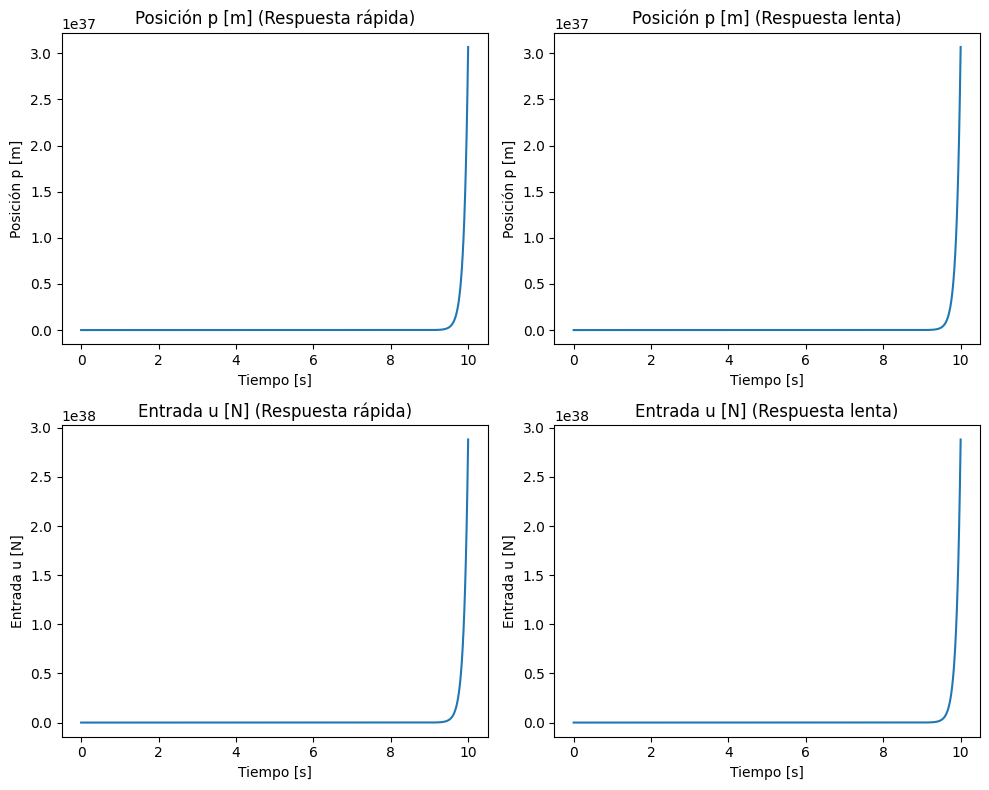

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import place_poles, StateSpace, step

# Parámetros del sistema
M = 10  # kg
m = 80  # kg
J = 100  # kg*m^2
l = 1    # m
r = 0.01  # N m s
g = 9.8  # m/s^2

# Definir los valores de matrices A y B
A = np.array([[0, 1, 0, 0],
              [0, 0, -(m*g)/M, r/M],
              [0, 0, 0, 1],
              [0, 0, (M+m)*g/(M*l), -r/(M*l)]])

B = np.array([[0],
              [1/M],
              [0],
              [-1/(M*l)]])

# Crear los sistemas StateSpace para respuestas rápida y lenta
sys_fast = StateSpace(A, B, np.eye(4), np.zeros((4, 1)))
sys_slow = StateSpace(A, B, np.eye(4), np.zeros((4, 1)))

# Tiempo de simulación
t = np.linspace(0, 10, 500)

# Simulación de la respuesta al escalón para ambos sistemas
t1, y1 = step(sys_fast, T=t)
t2, y2 = step(sys_slow, T=t)

# Gráficas organizadas correctamente
plt.figure(figsize=(10, 8))

# Respuesta rápida - Posición p [m]
plt.subplot(2, 2, 1)
plt.plot(t1, y1[:, 0])
plt.title('Posición p [m] (Respuesta rápida)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Posición p [m]')

# Respuesta lenta - Posición p [m]
plt.subplot(2, 2, 2)
plt.plot(t2, y2[:, 0])
plt.title('Posición p [m] (Respuesta lenta)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Posición p [m]')

# Respuesta rápida - Entrada u [N]
plt.subplot(2, 2, 3)
plt.plot(t1, y1[:, 1])
plt.title('Entrada u [N] (Respuesta rápida)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Entrada u [N]')

# Respuesta lenta - Entrada u [N]
plt.subplot(2, 2, 4)
plt.plot(t2, y2[:, 1])
plt.title('Entrada u [N] (Respuesta lenta)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Entrada u [N]')

plt.tight_layout()
plt.show()


In [10]:
import numpy as np

# Parámetros del sistema
M = 10  # kg
m = 80  # kg
J = 100  # kg*m^2
c = 0.01  # N s/m
l = 1    # m
gamma = 0.01  # N m s
g = 9.8  # m/s^2

# Cálculos intermedios
Mt = M + m
Jt = J + m * l**2
mu = Mt * Jt - (m * l)**2

# Definir los valores de matrices A y B
A = np.array([[0, 1, 0, 0],
              [0, 0, (m**2 * g * l) / mu, -gamma / mu],
              [0, 0, 0, 1],
              [0, 0, -(Mt * g * l) / mu, -c / mu]])

B = np.array([[0],
              [l / mu],
              [0],
              [Jt / mu]])

ValueError: at least one of the requested pole is repeated more than rank(B) times